In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

sns.set(style="whitegrid")


In [2]:
# Load the dataset
df = pd.read_csv("adult_income.csv")

# Clean strings and encode target
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

df['income'] = LabelEncoder().fit_transform(df['income'])

# Feature-target split
X = pd.get_dummies(df.drop('income', axis=1))
y = df['income']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [3]:
# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
log_preds = logreg.predict(X_test)

# Support Vector Machine
svm = SVC(probability=True)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)

# Decision Tree
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
tree_preds = tree.predict(X_test)


In [4]:
models = {
    "Logistic Regression": log_preds,
    "SVM": svm_preds,
    "Decision Tree": tree_preds
}

for name, preds in models.items():
    print(f"🔍 {name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Classification Report:")
    print(classification_report(y_test, preds))
    print("=" * 50)


🔍 Logistic Regression
Accuracy: 0.8570551205281745
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4942
           1       0.75      0.61      0.67      1571

    accuracy                           0.86      6513
   macro avg       0.82      0.77      0.79      6513
weighted avg       0.85      0.86      0.85      6513

🔍 SVM
Accuracy: 0.8506064793489944
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.91      4942
           1       0.76      0.56      0.64      1571

    accuracy                           0.85      6513
   macro avg       0.81      0.75      0.77      6513
weighted avg       0.84      0.85      0.84      6513

🔍 Decision Tree
Accuracy: 0.8504529402732995
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      4942
           1       0.79      0.52    

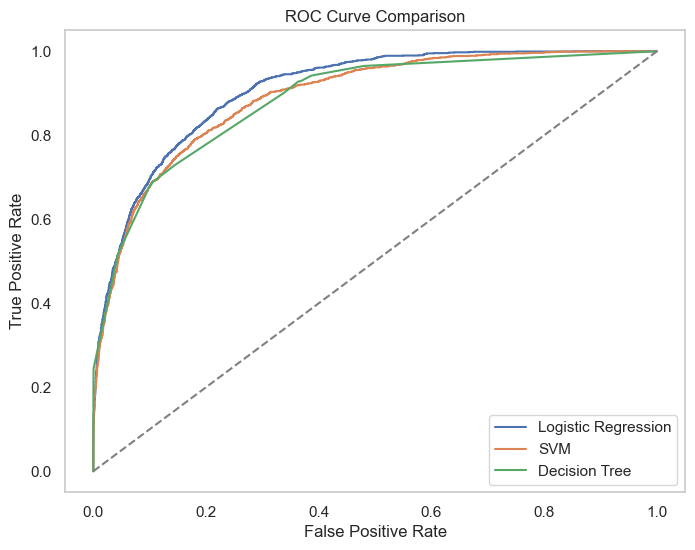

In [5]:
# Get probabilities for ROC
log_proba = logreg.predict_proba(X_test)[:, 1]
svm_proba = svm.predict_proba(X_test)[:, 1]
tree_proba = tree.predict_proba(X_test)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, log_proba)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_proba)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_svm, tpr_svm, label="SVM")
plt.plot(fpr_tree, tpr_tree, label="Decision Tree")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()
